In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 设置seaborn风格
sns.set_style("whitegrid")
sns.set_palette("pastel")

# 设置matplotlib的rc参数
plt.rcParams.update({
    'font.size': 12,             # 设置字体大小
    'text.usetex': False,       # 禁用TeX文本渲染
    'figure.dpi': 300,          # 设置图形分辨率
    'axes.linewidth': 1.5,      # 设置轴线宽度
    'axes.grid': False,        # 去掉网格线
    'xtick.labelsize': 10,      # 设置x轴标签大小
    'ytick.labelsize': 10,      # 设置y轴标签大小
    'legend.fontsize': 12,      # 设置图例字体大小
    'legend.frameon': True      # 显示图例边框
})

# 读取数据

In [4]:
# Load data (id column, unique identifier, as index)
train = pd.read_csv('D:/PostGraduate/SPbU/part2-1/Research Seminar in Digital Economy and Applied Problems/预测道路事故风险/train.csv',index_col='id')

In [5]:
# Take a quick look at the dataset information
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 41.5+ MB


In [6]:
# The first 5 data
train.head(5)

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


# 数据预处理

### 缺失值检测与处理

In [7]:
# 🔍 Check missing values for Training data（No missing values）
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print("\n🔹 Missing Values in Training Data:")
display(missing_train)


🔹 Missing Values in Training Data:


Series([], dtype: int64)

### 重复值处理

In [8]:
# Check if the entire dataframe has duplicate rows
if train.duplicated().any():
    print("There are duplicate rows, the duplicate rows are as follows:")
    print(train[train.duplicated()])
else:
    print("No duplicate rows.")

There are duplicate rows, the duplicate rows are as follows:
       road_type  num_lanes  curvature  speed_limit  lighting weather  \
id                                                                      
22658    highway          3       0.05           35       dim   rainy   
24586      urban          4       0.37           60  daylight   rainy   
37113    highway          2       0.29           35  daylight   clear   
42179    highway          2       0.62           45       dim   rainy   
42717    highway          4       0.07           35       dim   foggy   
...          ...        ...        ...          ...       ...     ...   
515300     urban          4       0.07           45  daylight   foggy   
515342     urban          3       0.29           70  daylight   rainy   
515385     urban          4       0.11           45  daylight   clear   
515662     rural          2       0.74           45       dim   foggy   
516778     rural          3       0.23           70  daylight  

In [9]:
# A total of 656 rows of duplicate data were found, which is not a large percentage, so they were deleted directly.
train_cleaned = train.drop_duplicates()

In [10]:
train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517098 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517098 non-null  object 
 1   num_lanes               517098 non-null  int64  
 2   curvature               517098 non-null  float64
 3   speed_limit             517098 non-null  int64  
 4   lighting                517098 non-null  object 
 5   weather                 517098 non-null  object 
 6   road_signs_present      517098 non-null  bool   
 7   public_road             517098 non-null  bool   
 8   time_of_day             517098 non-null  object 
 9   holiday                 517098 non-null  bool   
 10  school_season           517098 non-null  bool   
 11  num_reported_accidents  517098 non-null  int64  
 12  accident_risk           517098 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 41.4+ MB


### 特征编码：标签编码

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
# Identifying non-numeric columns（object、float）
non_numeric_columns = train_cleaned.select_dtypes(include=['object','bool']).columns

# Initialize LabelEncoder
le = LabelEncoder()

# Label encoding for non-numeric data columns
for column in non_numeric_columns:
    train_cleaned[column + '_Encoded'] = le.fit_transform(train_cleaned[column])
    
    # Get the mapping relationship of label encoding
    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    
    print(f"\n{column}Label encoding mapping relationship：")
    for original, encoded in label_mapping.items():
        print(f"{original}: {encoded}")


road_typeLabel encoding mapping relationship：
highway: 0
rural: 1
urban: 2

lightingLabel encoding mapping relationship：
daylight: 0
dim: 1
night: 2

weatherLabel encoding mapping relationship：
clear: 0
foggy: 1
rainy: 2

road_signs_presentLabel encoding mapping relationship：
False: 0
True: 1

public_roadLabel encoding mapping relationship：
False: 0
True: 1

time_of_dayLabel encoding mapping relationship：
afternoon: 0
evening: 1
morning: 2

holidayLabel encoding mapping relationship：
False: 0
True: 1

school_seasonLabel encoding mapping relationship：
False: 0
True: 1


In [13]:
non_numeric_columns

Index(['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road',
       'time_of_day', 'holiday', 'school_season'],
      dtype='object')

In [14]:
# Delete the original label encoding column
train_cleaned.drop(columns=non_numeric_columns,axis=1,inplace=True)

In [15]:
train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517098 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   num_lanes                   517098 non-null  int64  
 1   curvature                   517098 non-null  float64
 2   speed_limit                 517098 non-null  int64  
 3   num_reported_accidents      517098 non-null  int64  
 4   accident_risk               517098 non-null  float64
 5   road_type_Encoded           517098 non-null  int32  
 6   lighting_Encoded            517098 non-null  int32  
 7   weather_Encoded             517098 non-null  int32  
 8   road_signs_present_Encoded  517098 non-null  int64  
 9   public_road_Encoded         517098 non-null  int64  
 10  time_of_day_Encoded         517098 non-null  int32  
 11  holiday_Encoded             517098 non-null  int64  
 12  school_season_Encoded       517098 non-null  int64  
dtypes: float64(2), int3

### 离群值检测与处理

In [16]:
# Column names of all independent variables
Group_X = train_cleaned.columns.tolist()
Group_X.remove('accident_risk')
Group_X.remove('curvature')

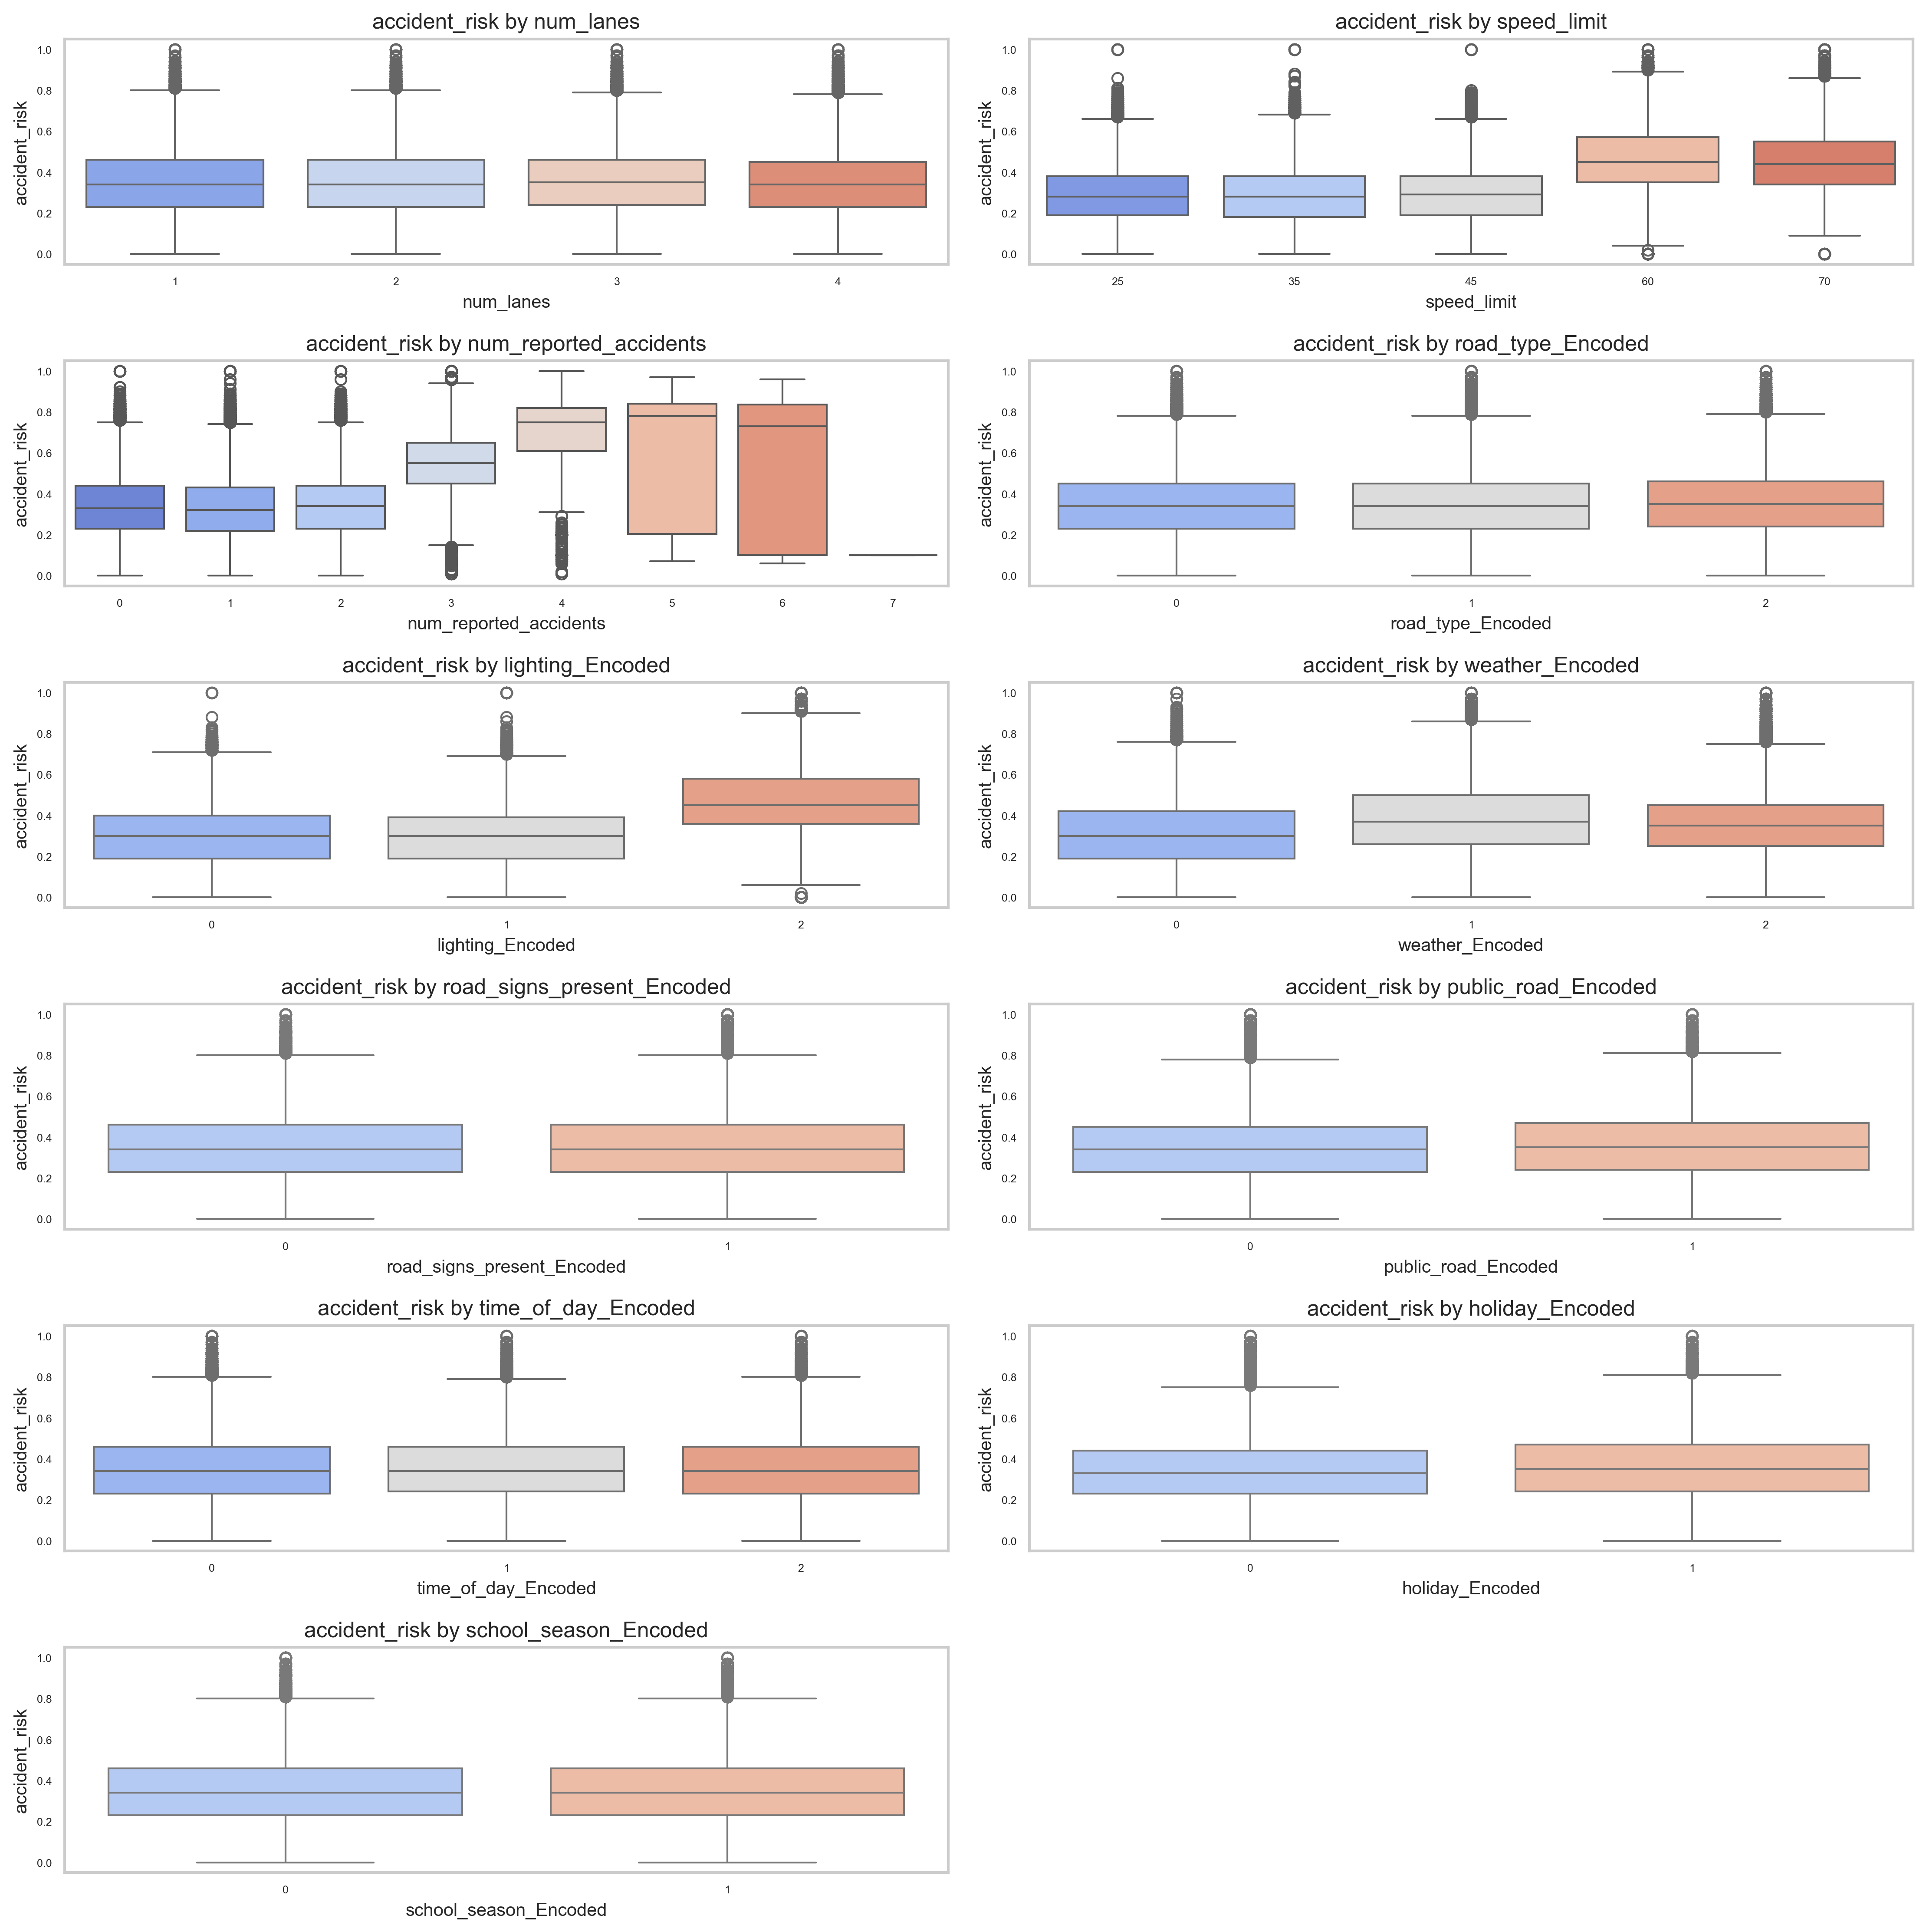

In [19]:
# Boxplot to view outliers
plt.figure(figsize=(15, 15))

for i, feature in enumerate(Group_X, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(x=feature, y='accident_risk', data=train_cleaned, palette="coolwarm" )
    plt.title(f'accident_risk by {feature}',fontsize=12)
    plt.xticks(fontsize=6)  # X轴标签字体大小
    plt.yticks(fontsize=6)  # Y轴标签字体大小
    plt.xlabel(feature, fontsize=10)  # X轴标题字体大小
    plt.ylabel('accident_risk', fontsize=10)  # Y轴标题字体大小

plt.tight_layout()
plt.show()

In [21]:
# LOF算法，Local Outlier Factor (识别异常值的)
from sklearn.neighbors import LocalOutlierFactor

In [22]:
scaler = LocalOutlierFactor()
scaler.fit(train_cleaned)
train_cleaned['LOF'] = - scaler.negative_outlier_factor_   # Add the ‘LOF’ column to the dataframe
train_cleaned[train_cleaned.LOF>1.5]  # Shows samples with a 'LOF' greater than 1.5  ( 51 )

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk,road_type_Encoded,lighting_Encoded,weather_Encoded,road_signs_present_Encoded,public_road_Encoded,time_of_day_Encoded,holiday_Encoded,school_season_Encoded,LOF
id,,,,,,,,,,,,,,
3243,2,0.14,45,5,0.10,2,2,1,1,0,2,1,1,1.651424
14291,3,0.05,45,4,0.01,1,1,0,1,0,2,0,1,1.592457
17687,3,0.86,25,5,0.74,0,2,0,0,0,0,1,0,1.507662
31916,3,0.12,35,5,0.20,2,2,0,1,0,1,1,1,1.576006
36794,1,0.10,70,5,0.16,0,0,0,0,1,0,1,1,1.817696
54342,1,0.00,35,5,0.20,1,2,2,1,1,2,1,1,1.688644
60437,2,0.27,35,7,0.10,2,2,0,0,1,1,1,0,1.855405
75472,2,0.02,60,5,0.20,0,2,0,1,0,0,1,1,1.548475
77456,1,0.33,45,5,0.10,1,2,1,1,1,2,0,0,1.777147


In [23]:
train_cleaned[train_cleaned.LOF>1.5].shape  # 51 条数据的 LOF > 1.5

(51, 14)

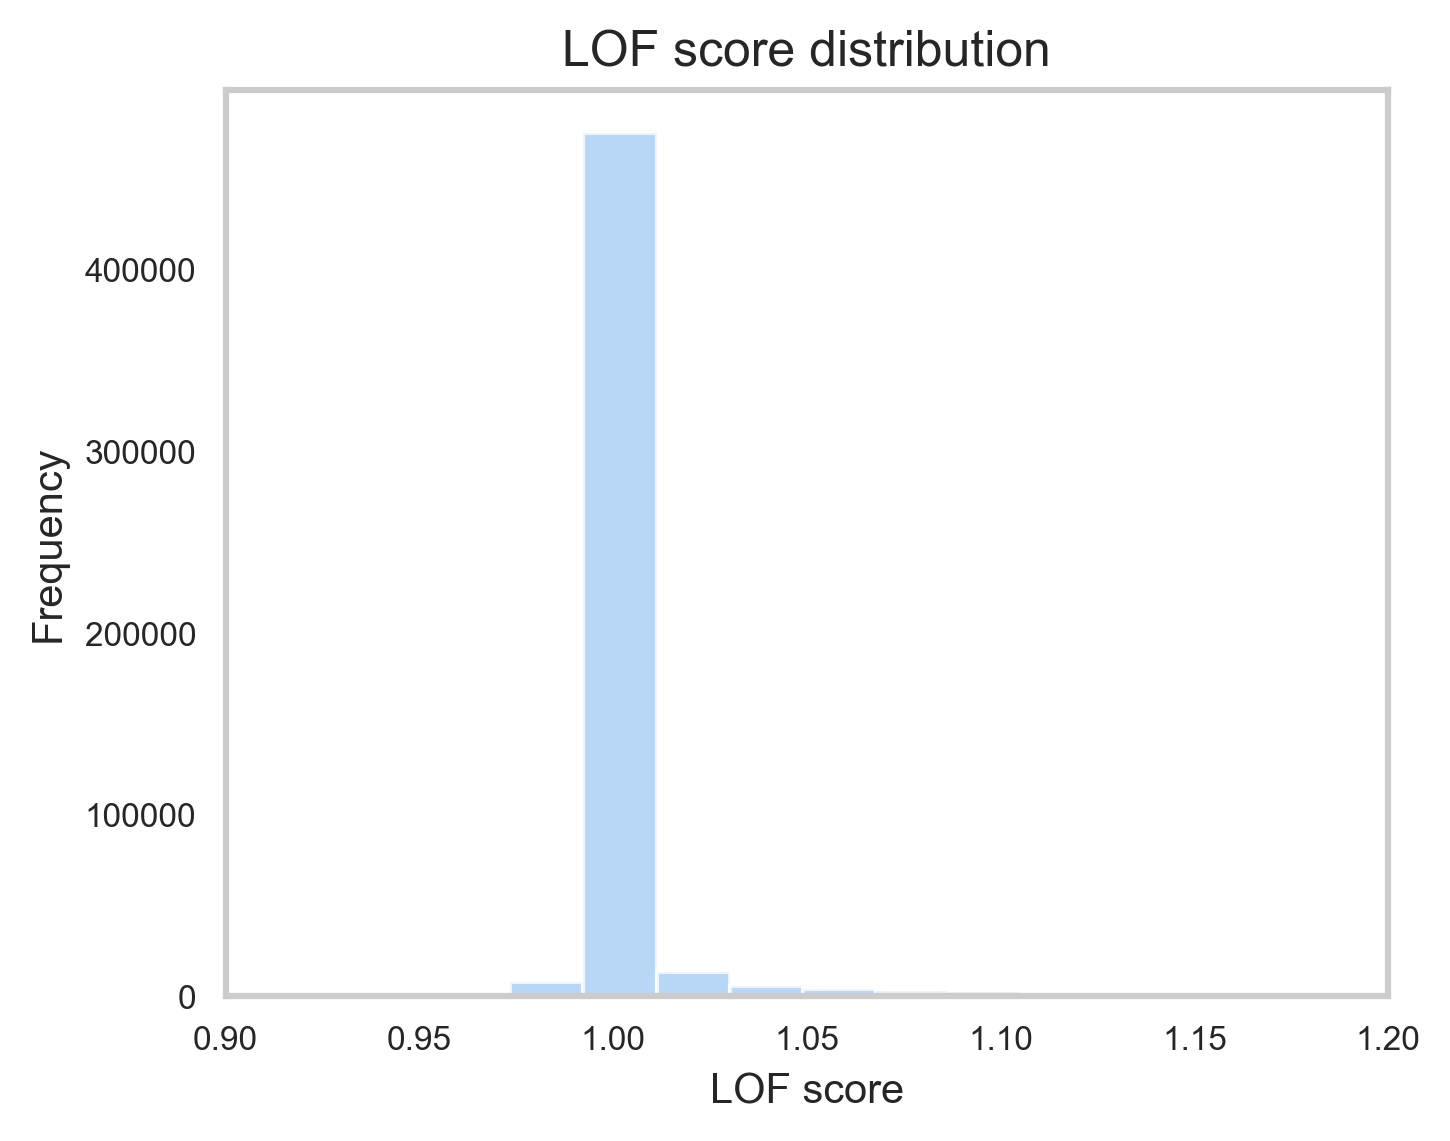

In [31]:
# Plotting the distribution of LOF scores
plt.figure(figsize=(5,4))
plt.hist(train_cleaned['LOF'], bins=50, alpha=0.75)
plt.xlim(0.9, 1.2)
plt.xlabel('LOF score', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.xticks(fontsize=8)  # X轴刻度字体大小
plt.yticks(fontsize=8)  # Y轴刻度字体大小
plt.title('LOF score distribution', fontsize=12)
plt.show()

In [32]:
# Only keep rows with LOF <= 1.5, that is, delete values with LOF > 1.5
train_cleaned = train_cleaned[train_cleaned['LOF'] <= 1.5]
# Delete the LOF column
train_cleaned = train_cleaned.drop('LOF', axis=1)

In [33]:
train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517047 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   num_lanes                   517047 non-null  int64  
 1   curvature                   517047 non-null  float64
 2   speed_limit                 517047 non-null  int64  
 3   num_reported_accidents      517047 non-null  int64  
 4   accident_risk               517047 non-null  float64
 5   road_type_Encoded           517047 non-null  int32  
 6   lighting_Encoded            517047 non-null  int32  
 7   weather_Encoded             517047 non-null  int32  
 8   road_signs_present_Encoded  517047 non-null  int64  
 9   public_road_Encoded         517047 non-null  int64  
 10  time_of_day_Encoded         517047 non-null  int32  
 11  holiday_Encoded             517047 non-null  int64  
 12  school_season_Encoded       517047 non-null  int64  
dtypes: float64(2), int3

### 数据标准化：懒得标准化了，这里就不写了

### 相关性分析：我们之前用的好像是 Pearson 相关系数，老师说这个需要数据服从正态分布，我换成 Spearman 秩相关系数（AI说这个不需要正态性假设）

In [34]:
# Calculate the Spearman correlation coefficient matrix
spearman_corr = train_cleaned.corr(method='spearman')

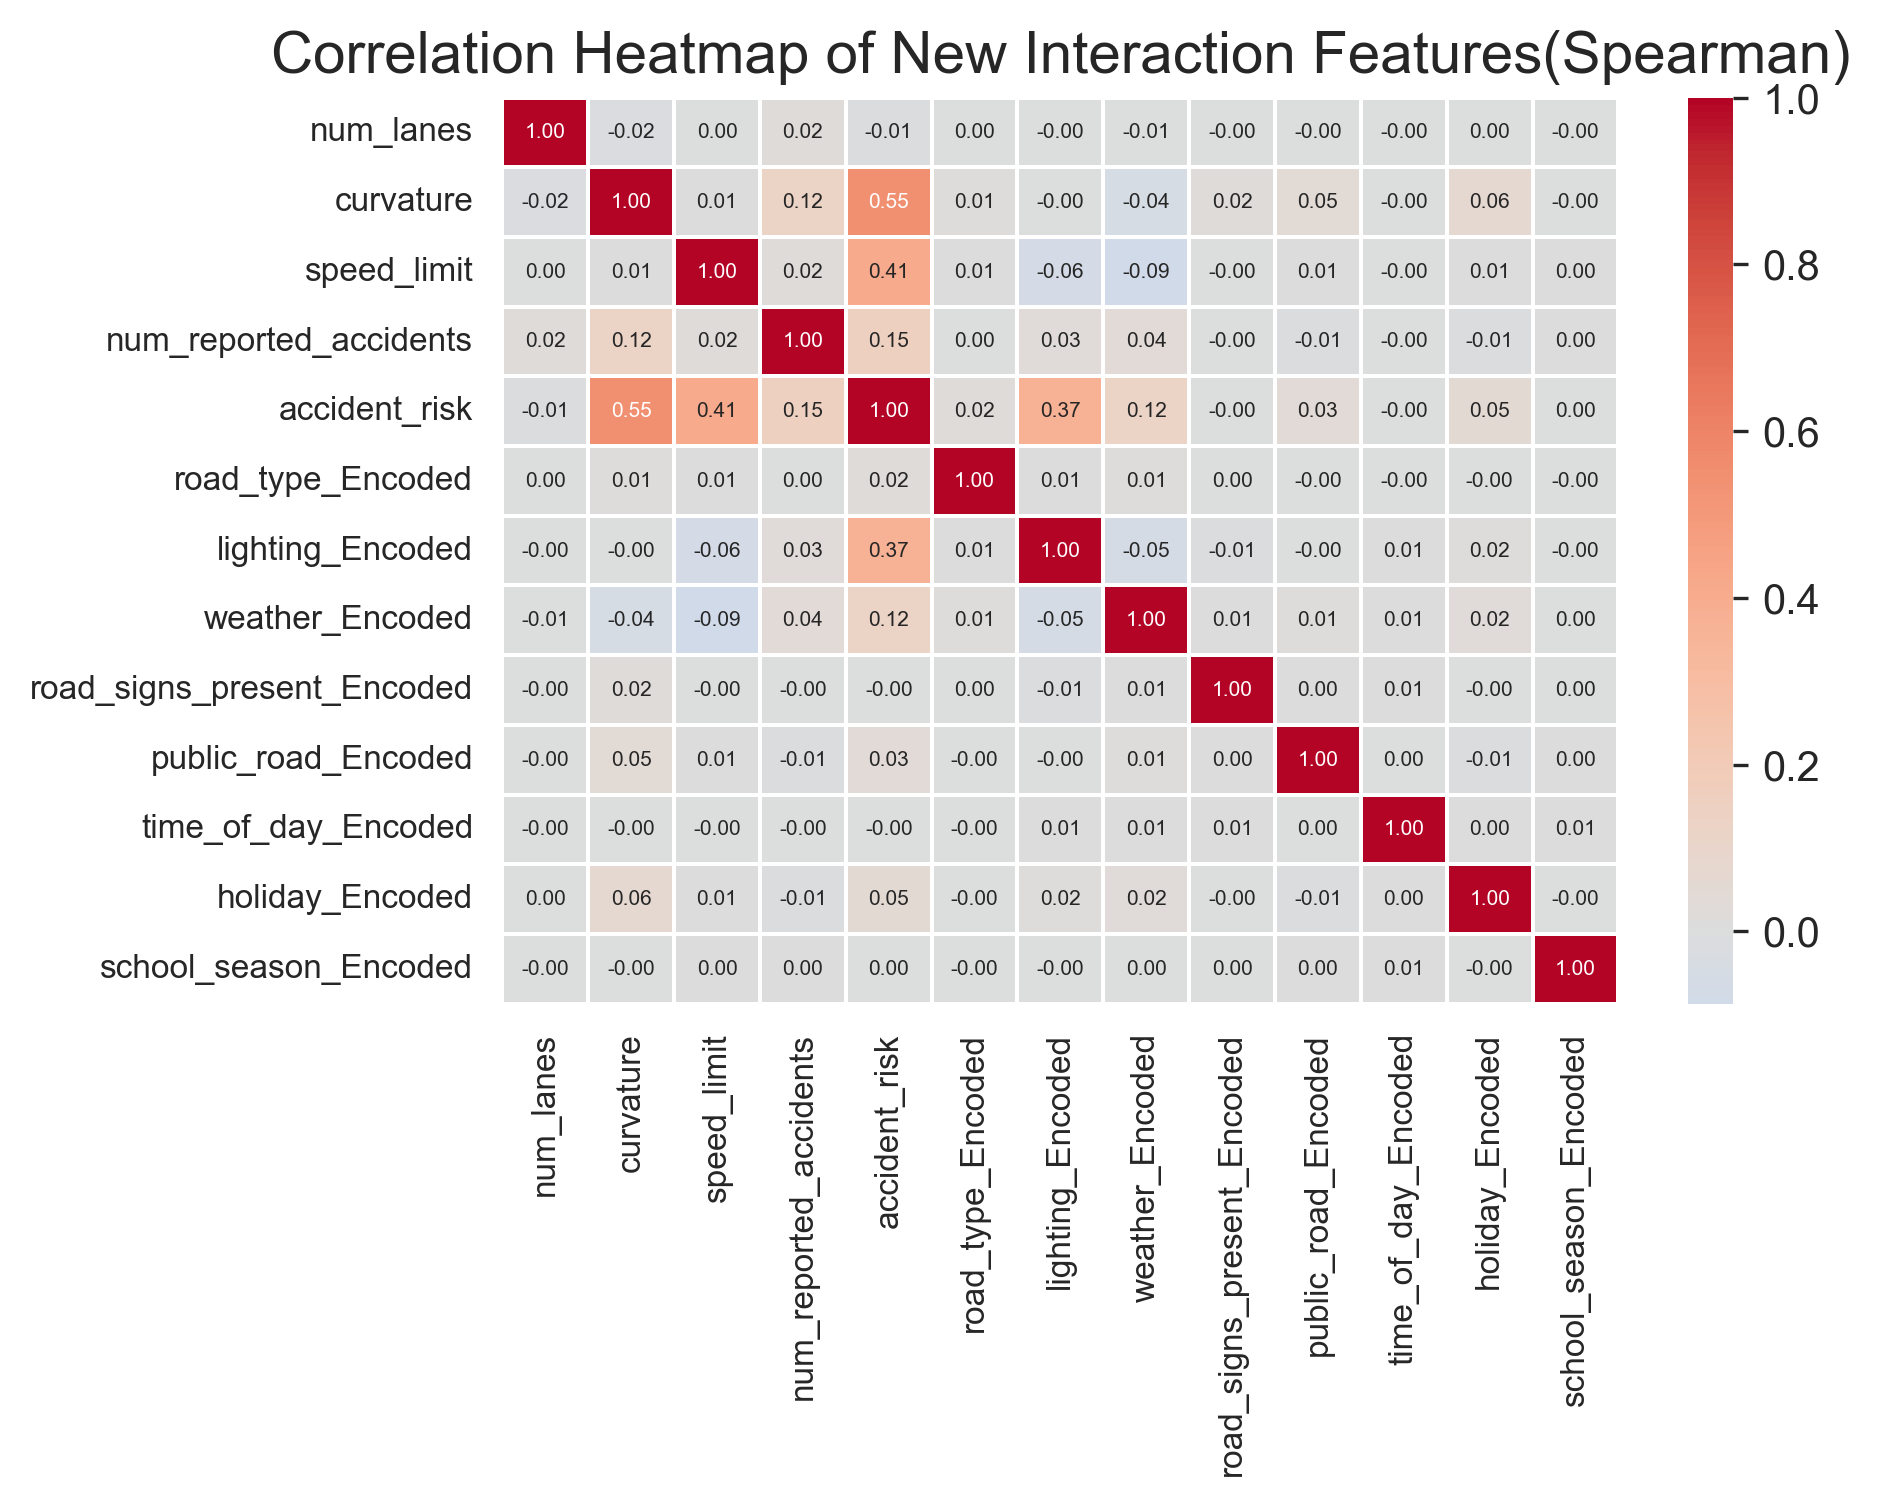

In [38]:
# heat map(相关性依然感觉不太高)
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 5}
)
plt.title("Correlation Heatmap of New Interaction Features(Spearman)", fontsize=14)
plt.xticks(fontsize=8)  # X轴标签字体大小
plt.yticks(fontsize=8)  # Y轴标签字体大小
plt.show()

### 特征融合 

      特征名      	    含义	        解释价值

    speed_curv	     速度 × 弯道     高速转弯危险

    light_speed    	  光照 × 速度      夜间高速风险

    night_bad_weather  夜间+恶劣天气	    复合环境风险
    
    school_zone_risk   学校区域限速	   儿童区域安全

    road_complexity   弯道 × 车道数	    路况复杂性

    speed_no_sign    限速 × 无交通标志   规则缺失风险


In [39]:
train_cleaned['speed_curv'] = train_cleaned['speed_limit'] * train_cleaned['curvature']
train_cleaned['light_speed'] = train_cleaned['lighting_Encoded'] * train_cleaned['speed_limit']
train_cleaned['night_bad_weather'] = ((train_cleaned['lighting_Encoded'] == 2) & (train_cleaned['weather_Encoded'] > 0)).astype(int)
train_cleaned['school_zone_risk'] = train_cleaned['school_season_Encoded'] * train_cleaned['speed_limit']
train_cleaned['road_complexity'] = train_cleaned['curvature'] * (train_cleaned['num_lanes'] + 1)
train_cleaned['speed_no_sign'] = train_cleaned['speed_limit'] * (train_cleaned['road_signs_present_Encoded'] == 0).astype(int)

### 相关性分析

In [40]:
spearman_corr = train_cleaned.corr(method='spearman')

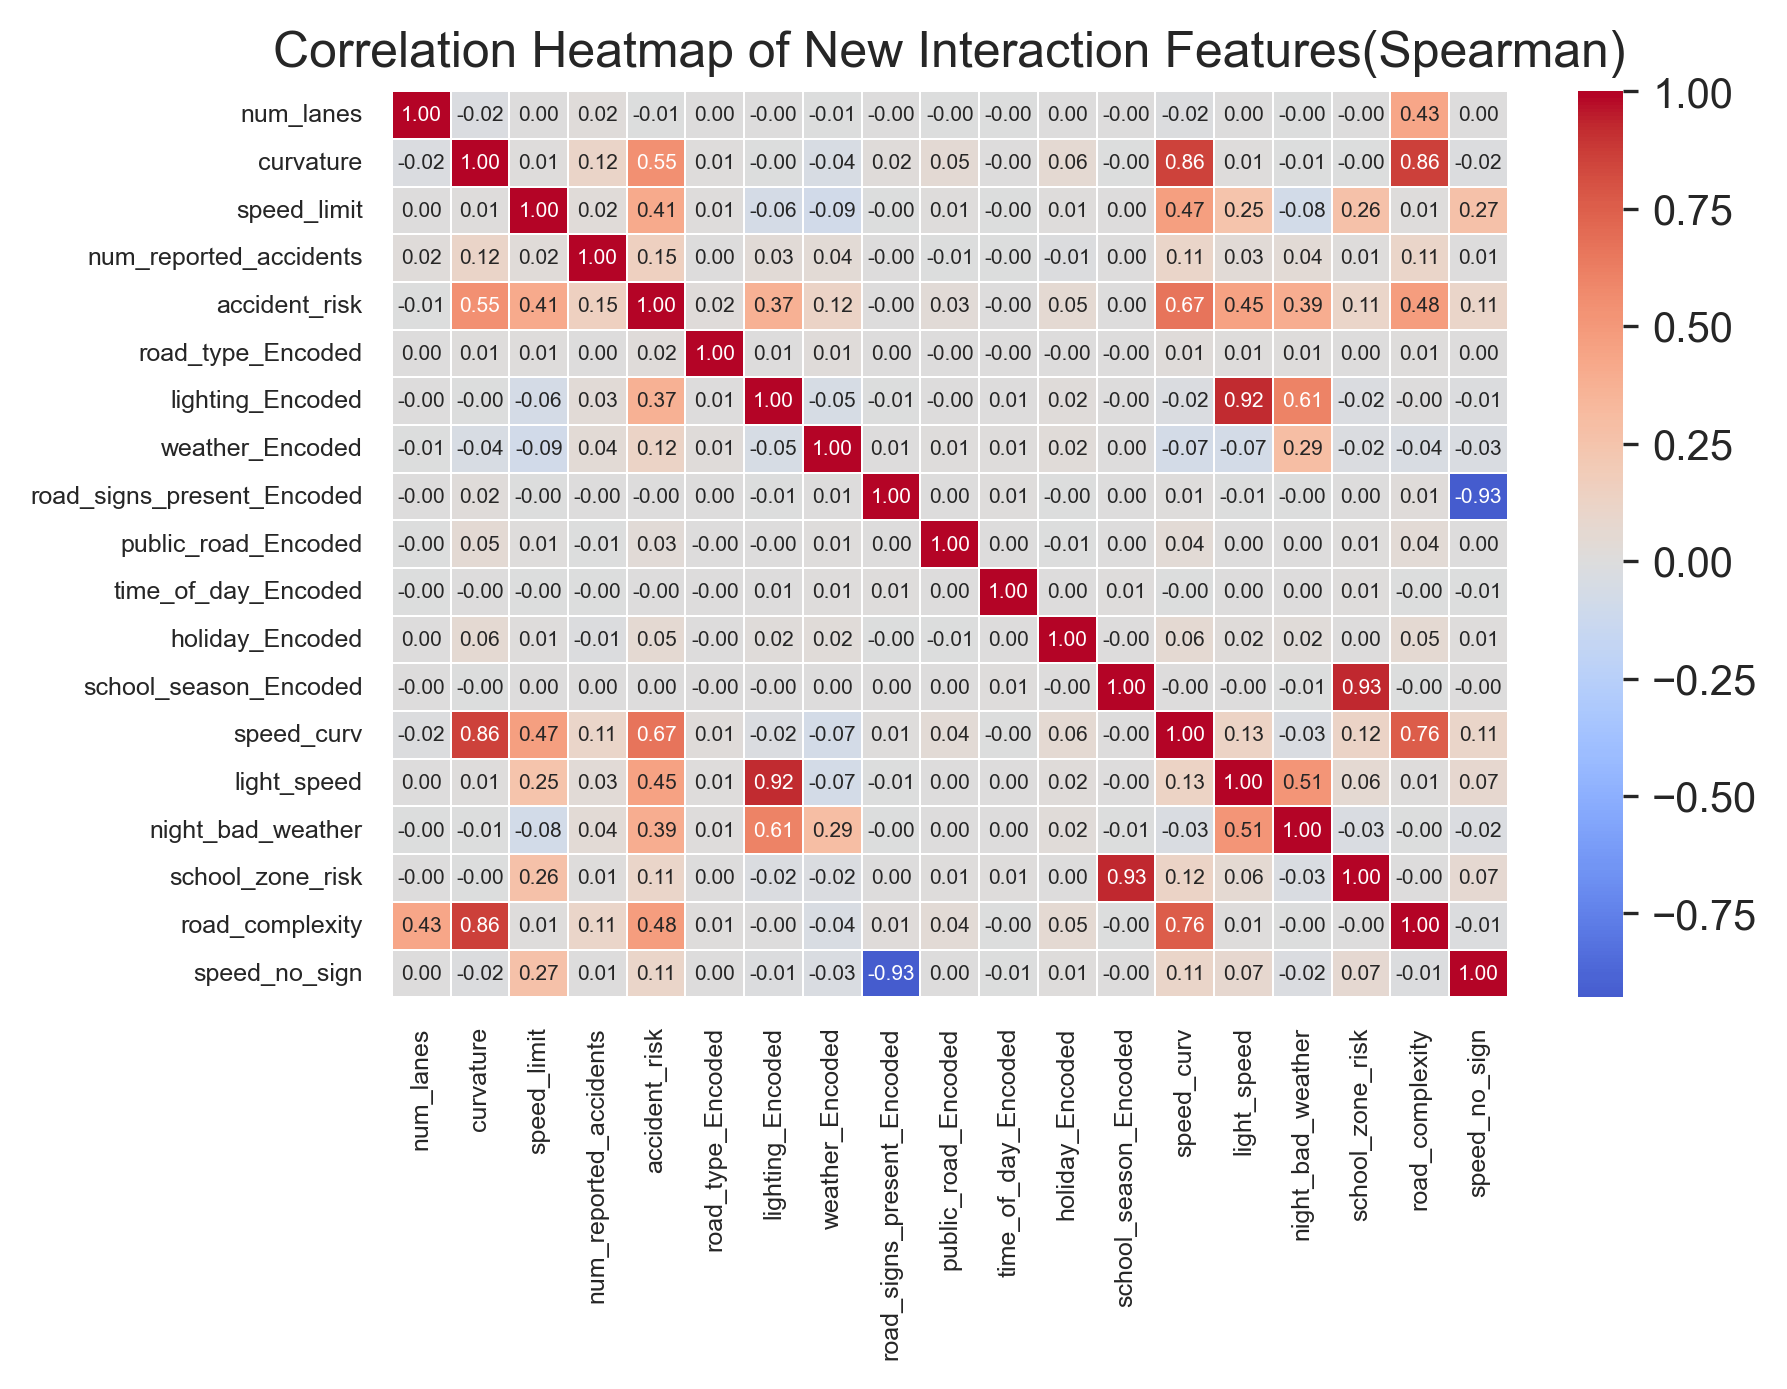

In [42]:
# heat map
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    annot_kws={"size": 5},
    linewidths=0.1
)
plt.title("Correlation Heatmap of New Interaction Features(Spearman)", fontsize=12)
plt.xticks(fontsize=6)  # X轴标签字体大小
plt.yticks(fontsize=6)  # Y轴标签字体大小
plt.show()

特征选择:“mutual_info_regression”计算互信息，用于回归问题

In [43]:
X_cols = ['num_lanes','curvature','speed_limit','num_reported_accidents','road_type_Encoded','lighting_Encoded','weather_Encoded','road_signs_present_Encoded','public_road_Encoded','time_of_day_Encoded','holiday_Encoded','school_season_Encoded','speed_curv','light_speed','night_bad_weather','school_zone_risk','road_complexity','speed_no_sign']
y_col = ['accident_risk']

In [44]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression

In [45]:
# 与目标变量最相关的11个特征
sel_reg = SelectKBest(mutual_info_regression,k=11).fit(train_cleaned[X_cols], train_cleaned[y_col])

In [47]:
[round(i,4) for i in sel_reg.scores_]  # 相关程度得分

[0.0003,
 0.2869,
 0.1491,
 0.0725,
 0.0008,
 0.1309,
 0.0338,
 0.0,
 0.0011,
 0.0012,
 0.0018,
 0.0007,
 0.4414,
 0.2873,
 0.1027,
 0.0739,
 0.2301,
 0.0752]

In [49]:
# 返回筛选结果
print(pd.Series(sel_reg.get_support(), index=X_cols))

num_lanes                     False
curvature                      True
speed_limit                    True
num_reported_accidents         True
road_type_Encoded             False
lighting_Encoded               True
weather_Encoded                True
road_signs_present_Encoded    False
public_road_Encoded           False
time_of_day_Encoded           False
holiday_Encoded               False
school_season_Encoded         False
speed_curv                     True
light_speed                    True
night_bad_weather              True
school_zone_risk               True
road_complexity                True
speed_no_sign                  True
dtype: bool


In [50]:
X_cols_selected = ['curvature','speed_limit','num_reported_accidents','lighting_Encoded','weather_Encoded',
                   'speed_curv','light_speed','night_bad_weather','school_zone_risk','road_complexity',
                   'speed_no_sign']

# 模型建立

### 划分测试集和训练集

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train,X_test,y_train,y_test=train_test_split(train_cleaned[X_cols_selected],train_cleaned['accident_risk'],test_size=0.2,random_state=1)

### 1.线性回归

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,median_absolute_error,r2_score

In [54]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [55]:
# 输出截距和系数
coefficients = pd.Series(data=np.round(lr.coef_,4),index=X_test.columns)
print(coefficients)
print("The intercept of this linear regression is:",np.round(lr.intercept_,4))

curvature                 0.2973
speed_limit               0.0048
num_reported_accidents    0.0169
lighting_Encoded          0.0604
weather_Encoded           0.0283
speed_curv                0.0006
light_speed              -0.0001
night_bad_weather         0.1086
school_zone_risk          0.0000
road_complexity           0.0011
speed_no_sign             0.0000
dtype: float64
The intercept of this linear regression is: -0.1518


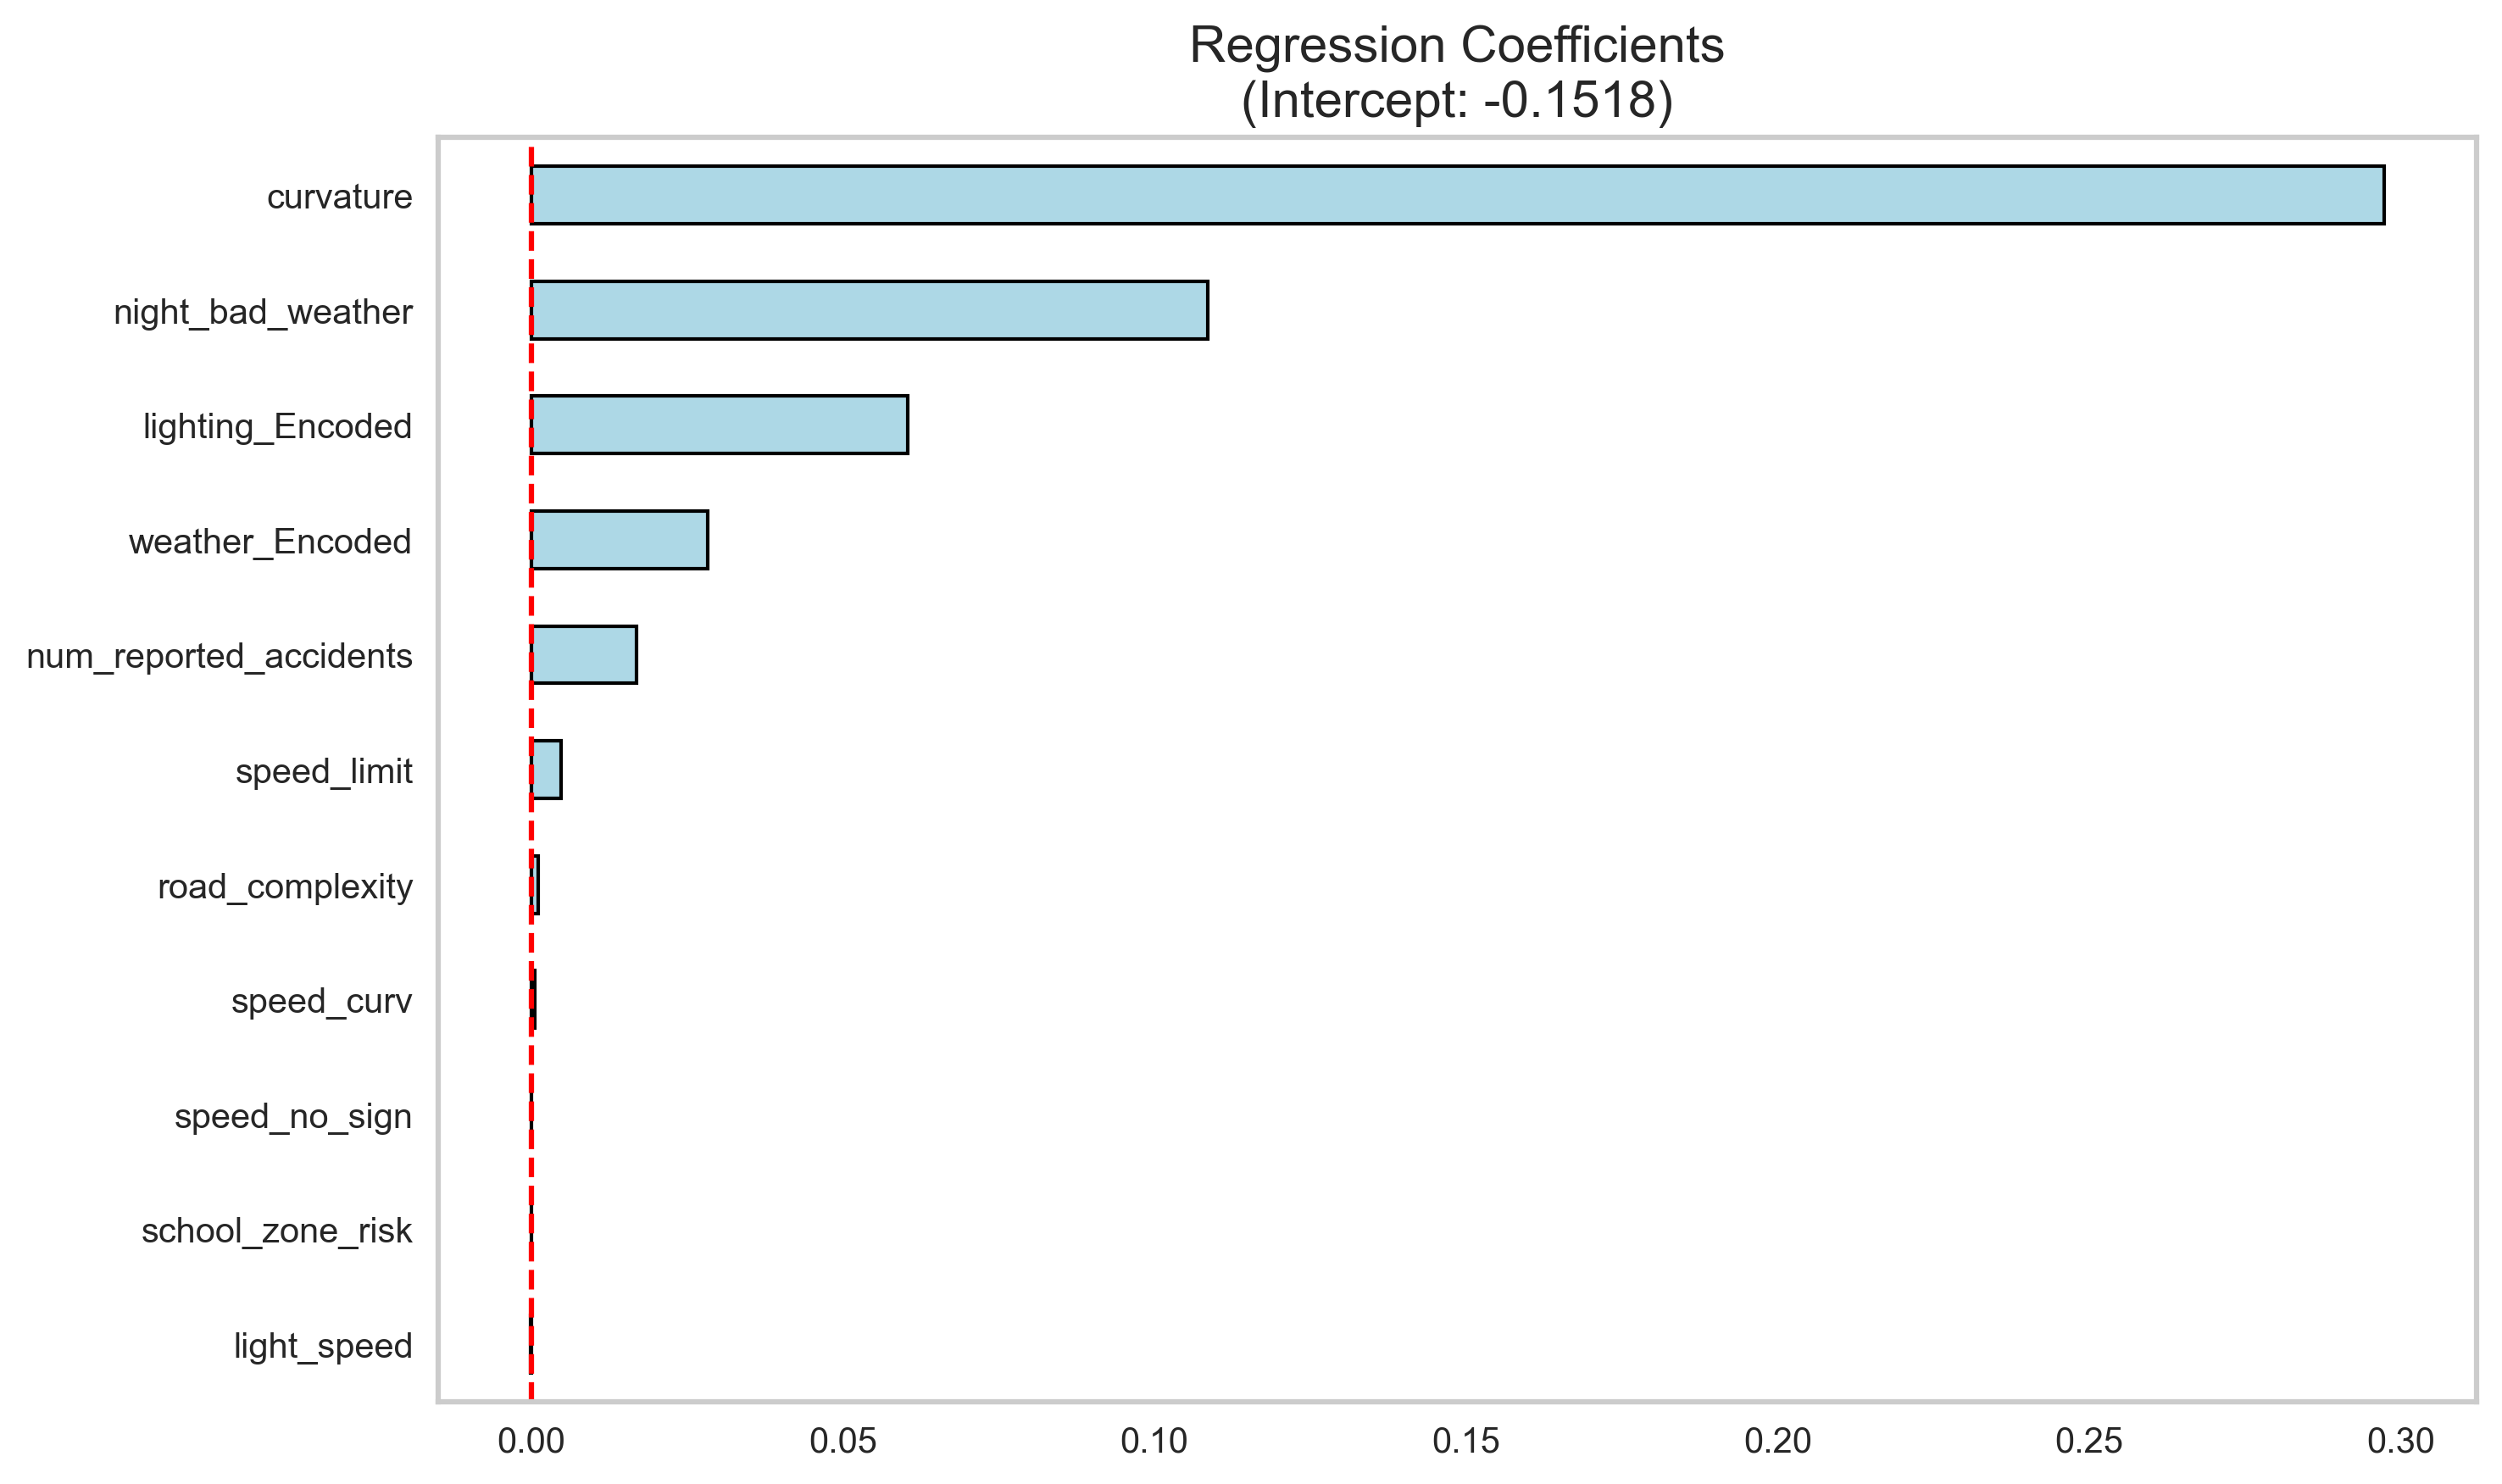

In [56]:
# 回归系数可视化
plt.figure(figsize=(10, 6))
coefficients.sort_values().plot(kind='barh', color='lightblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.title(f'Regression Coefficients\n(Intercept: {np.round(lr.intercept_, 4)})')
plt.tight_layout()
plt.show()

In [57]:
# 预测
lr_pred=lr.predict(X_test)
lr_pred_train=lr.predict(X_train)

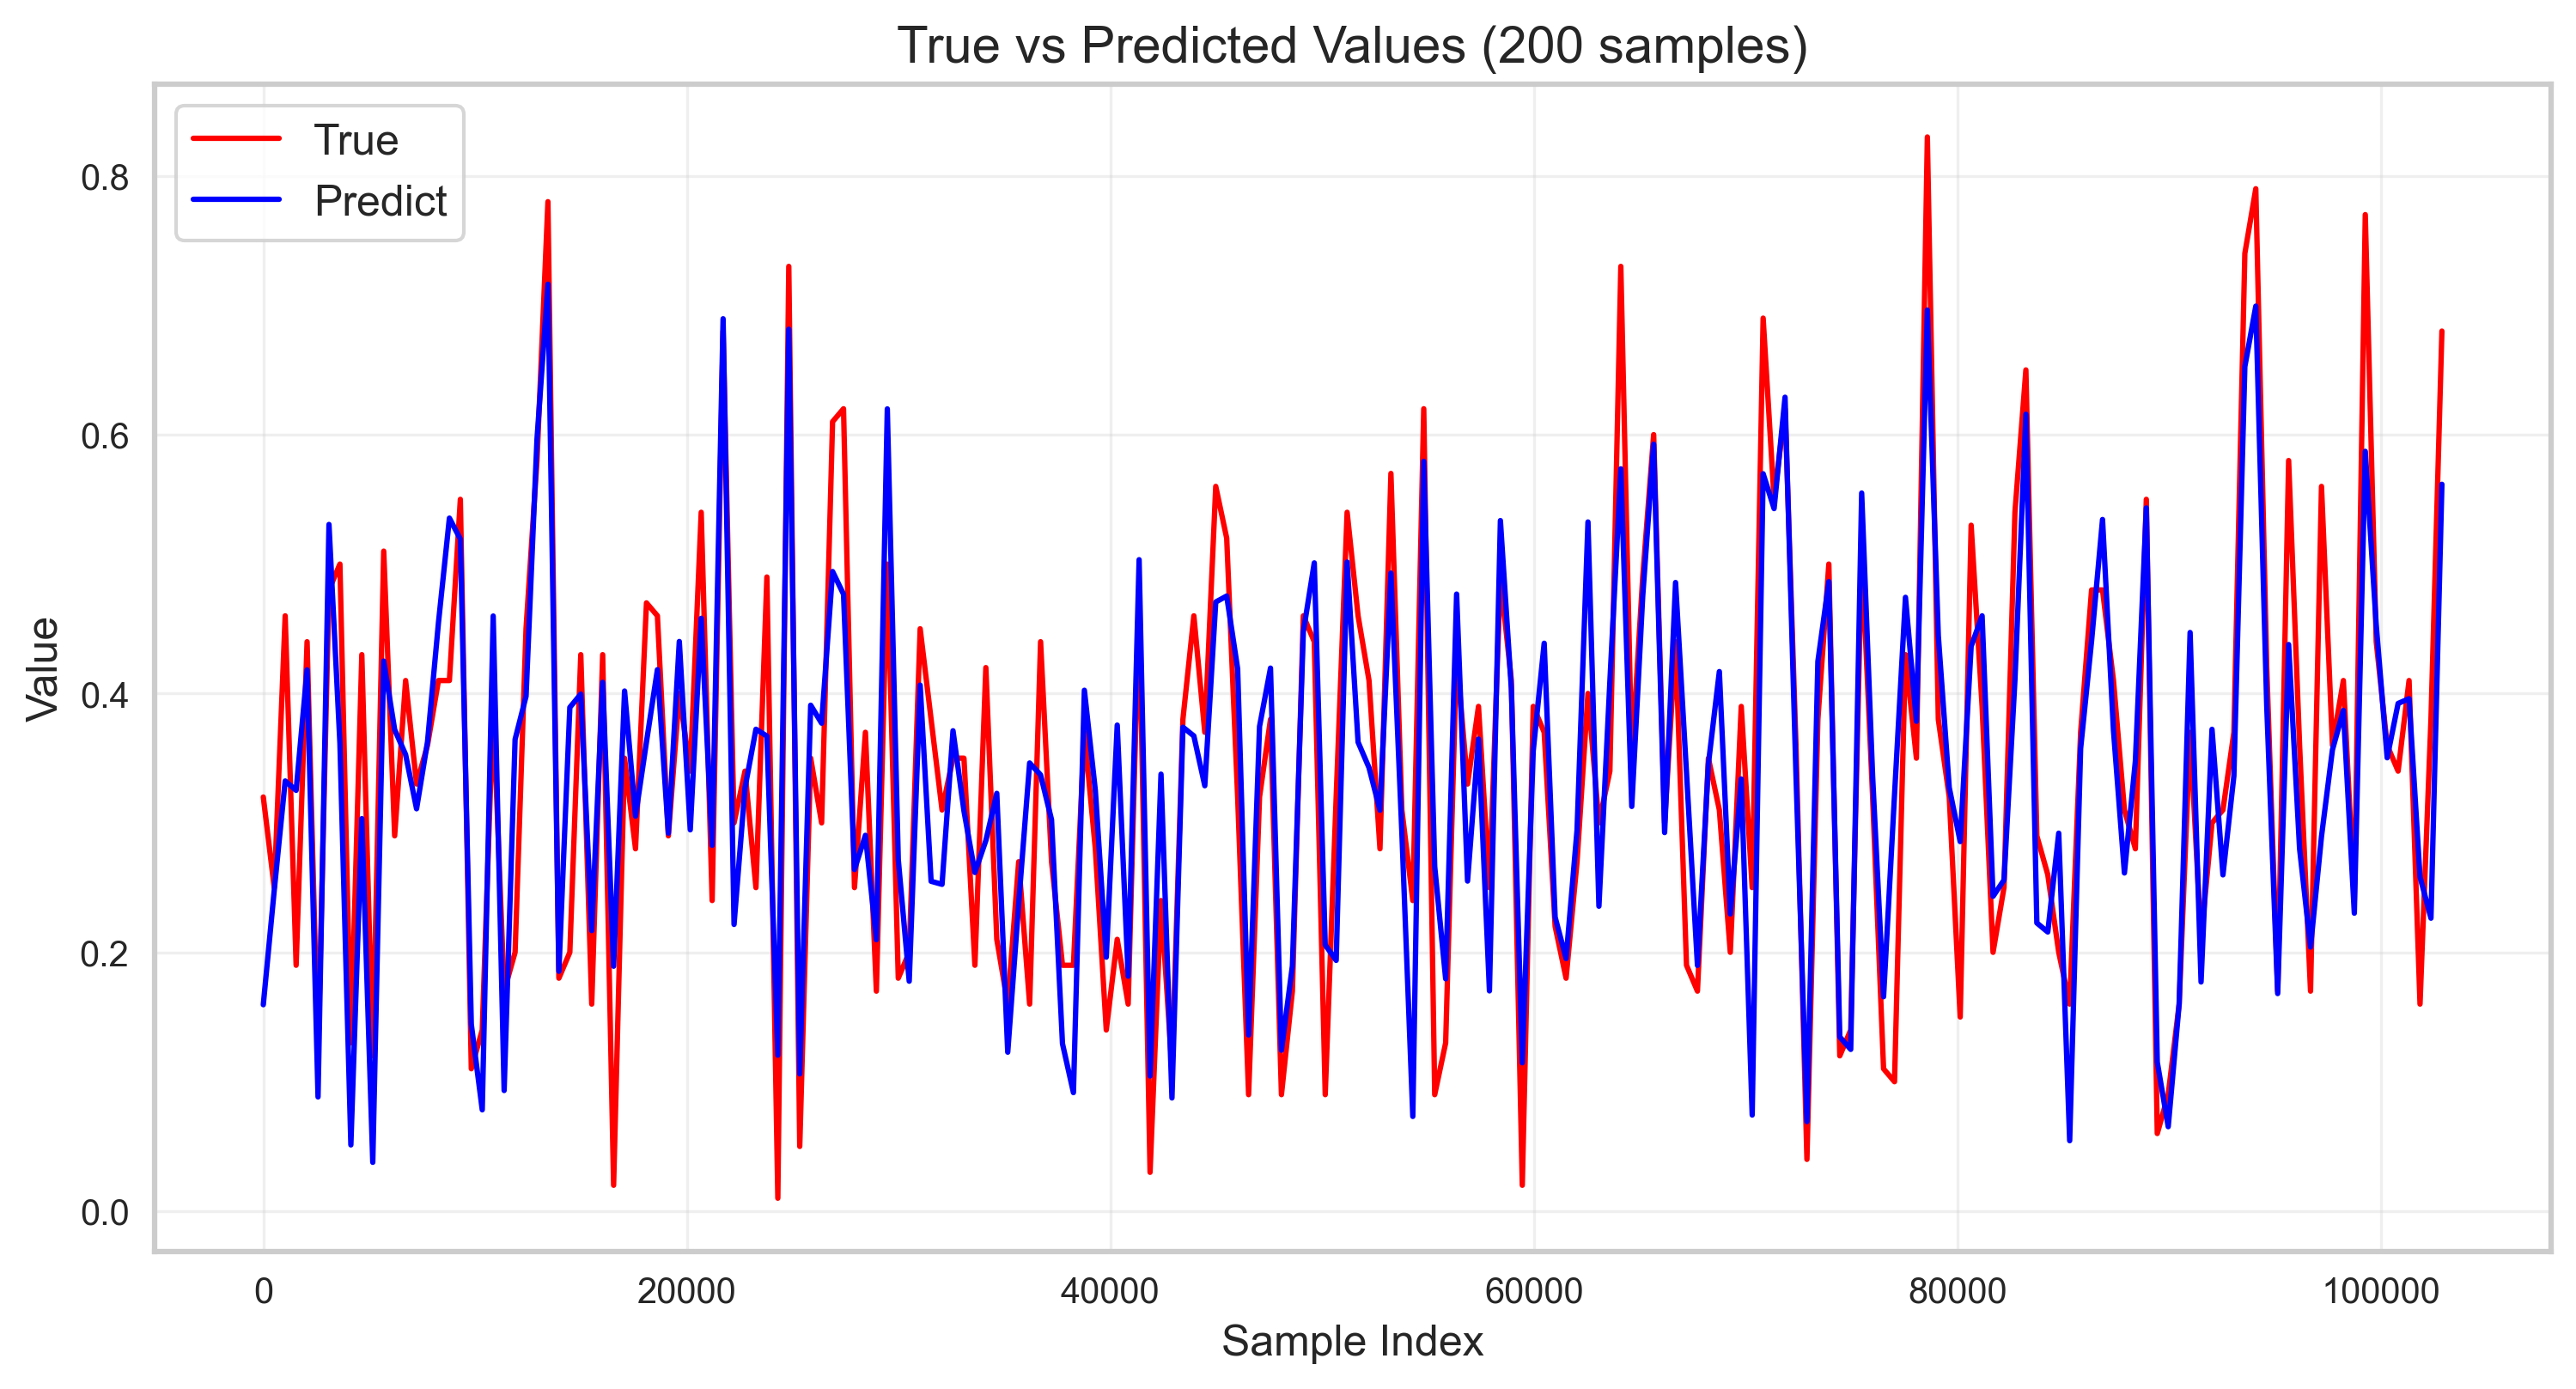

In [58]:
# 抽取200条数据
total_samples = len(y_test)
n_samples = 200

# 均匀抽样
if total_samples > n_samples:
    step = total_samples // n_samples
    indices = list(range(0, total_samples, step))[:n_samples]
else:
    indices = list(range(total_samples))

# 抽样数据
y_test_sampled = [y_test.to_list()[i] for i in indices]
lr_pred_sampled = [lr_pred[i] for i in indices]

# 绘制图形
plt.figure(figsize=(12,6))
plt.plot(indices, y_test_sampled, "r", label="True")
plt.plot(indices, lr_pred_sampled, "b", label="Predict")
plt.legend()
plt.title(f"True vs Predicted Values ({len(indices)} samples)")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
# Model Evaluation
print("Training Set Mean Squared Error (MSE): ", round(mean_squared_error(y_train, lr_pred_train), 4))
print("Training Set Mean Absolute Error(MAE): ", round(mean_absolute_error(y_train, lr_pred_train), 4))
print("Training Set Median Absolute Error(MedAE): ", round(median_absolute_error(y_train, lr_pred_train), 4))
print("Training Set R-squared(R²): ", round(r2_score(y_train, lr_pred_train), 4))
print("-" * 30)
print("Test Set Mean Squared Error(MSE): ", round(mean_squared_error(y_test, lr_pred), 4))
print("Test Set Mean Absolute Error(MAE): ", round(mean_absolute_error(y_test, lr_pred), 4))
print("Test Set Median Absolute Error(MedAE): ", round(median_absolute_error(y_test, lr_pred), 4))
print("Test Set R-squared: (R²)", round(r2_score(y_test, lr_pred), 4))

Training Set Mean Squared Error (MSE):  0.0069
Training Set Mean Absolute Error(MAE):  0.0663
Training Set Median Absolute Error(MedAE):  0.0562
Training Set R-squared(R²):  0.7508
------------------------------
Test Set Mean Squared Error(MSE):  0.0069
Test Set Mean Absolute Error(MAE):  0.0662
Test Set Median Absolute Error(MedAE):  0.0561
Test Set R-squared: (R²) 0.7501


### 2.岭回归

In [62]:
from sklearn.linear_model import Ridge

In [63]:
ri = Ridge()
ri.fit(X_train,y_train)

Ridge()

In [64]:
ri_pred = ri.predict(X_test)
ri_pred_train = ri.predict(X_train)

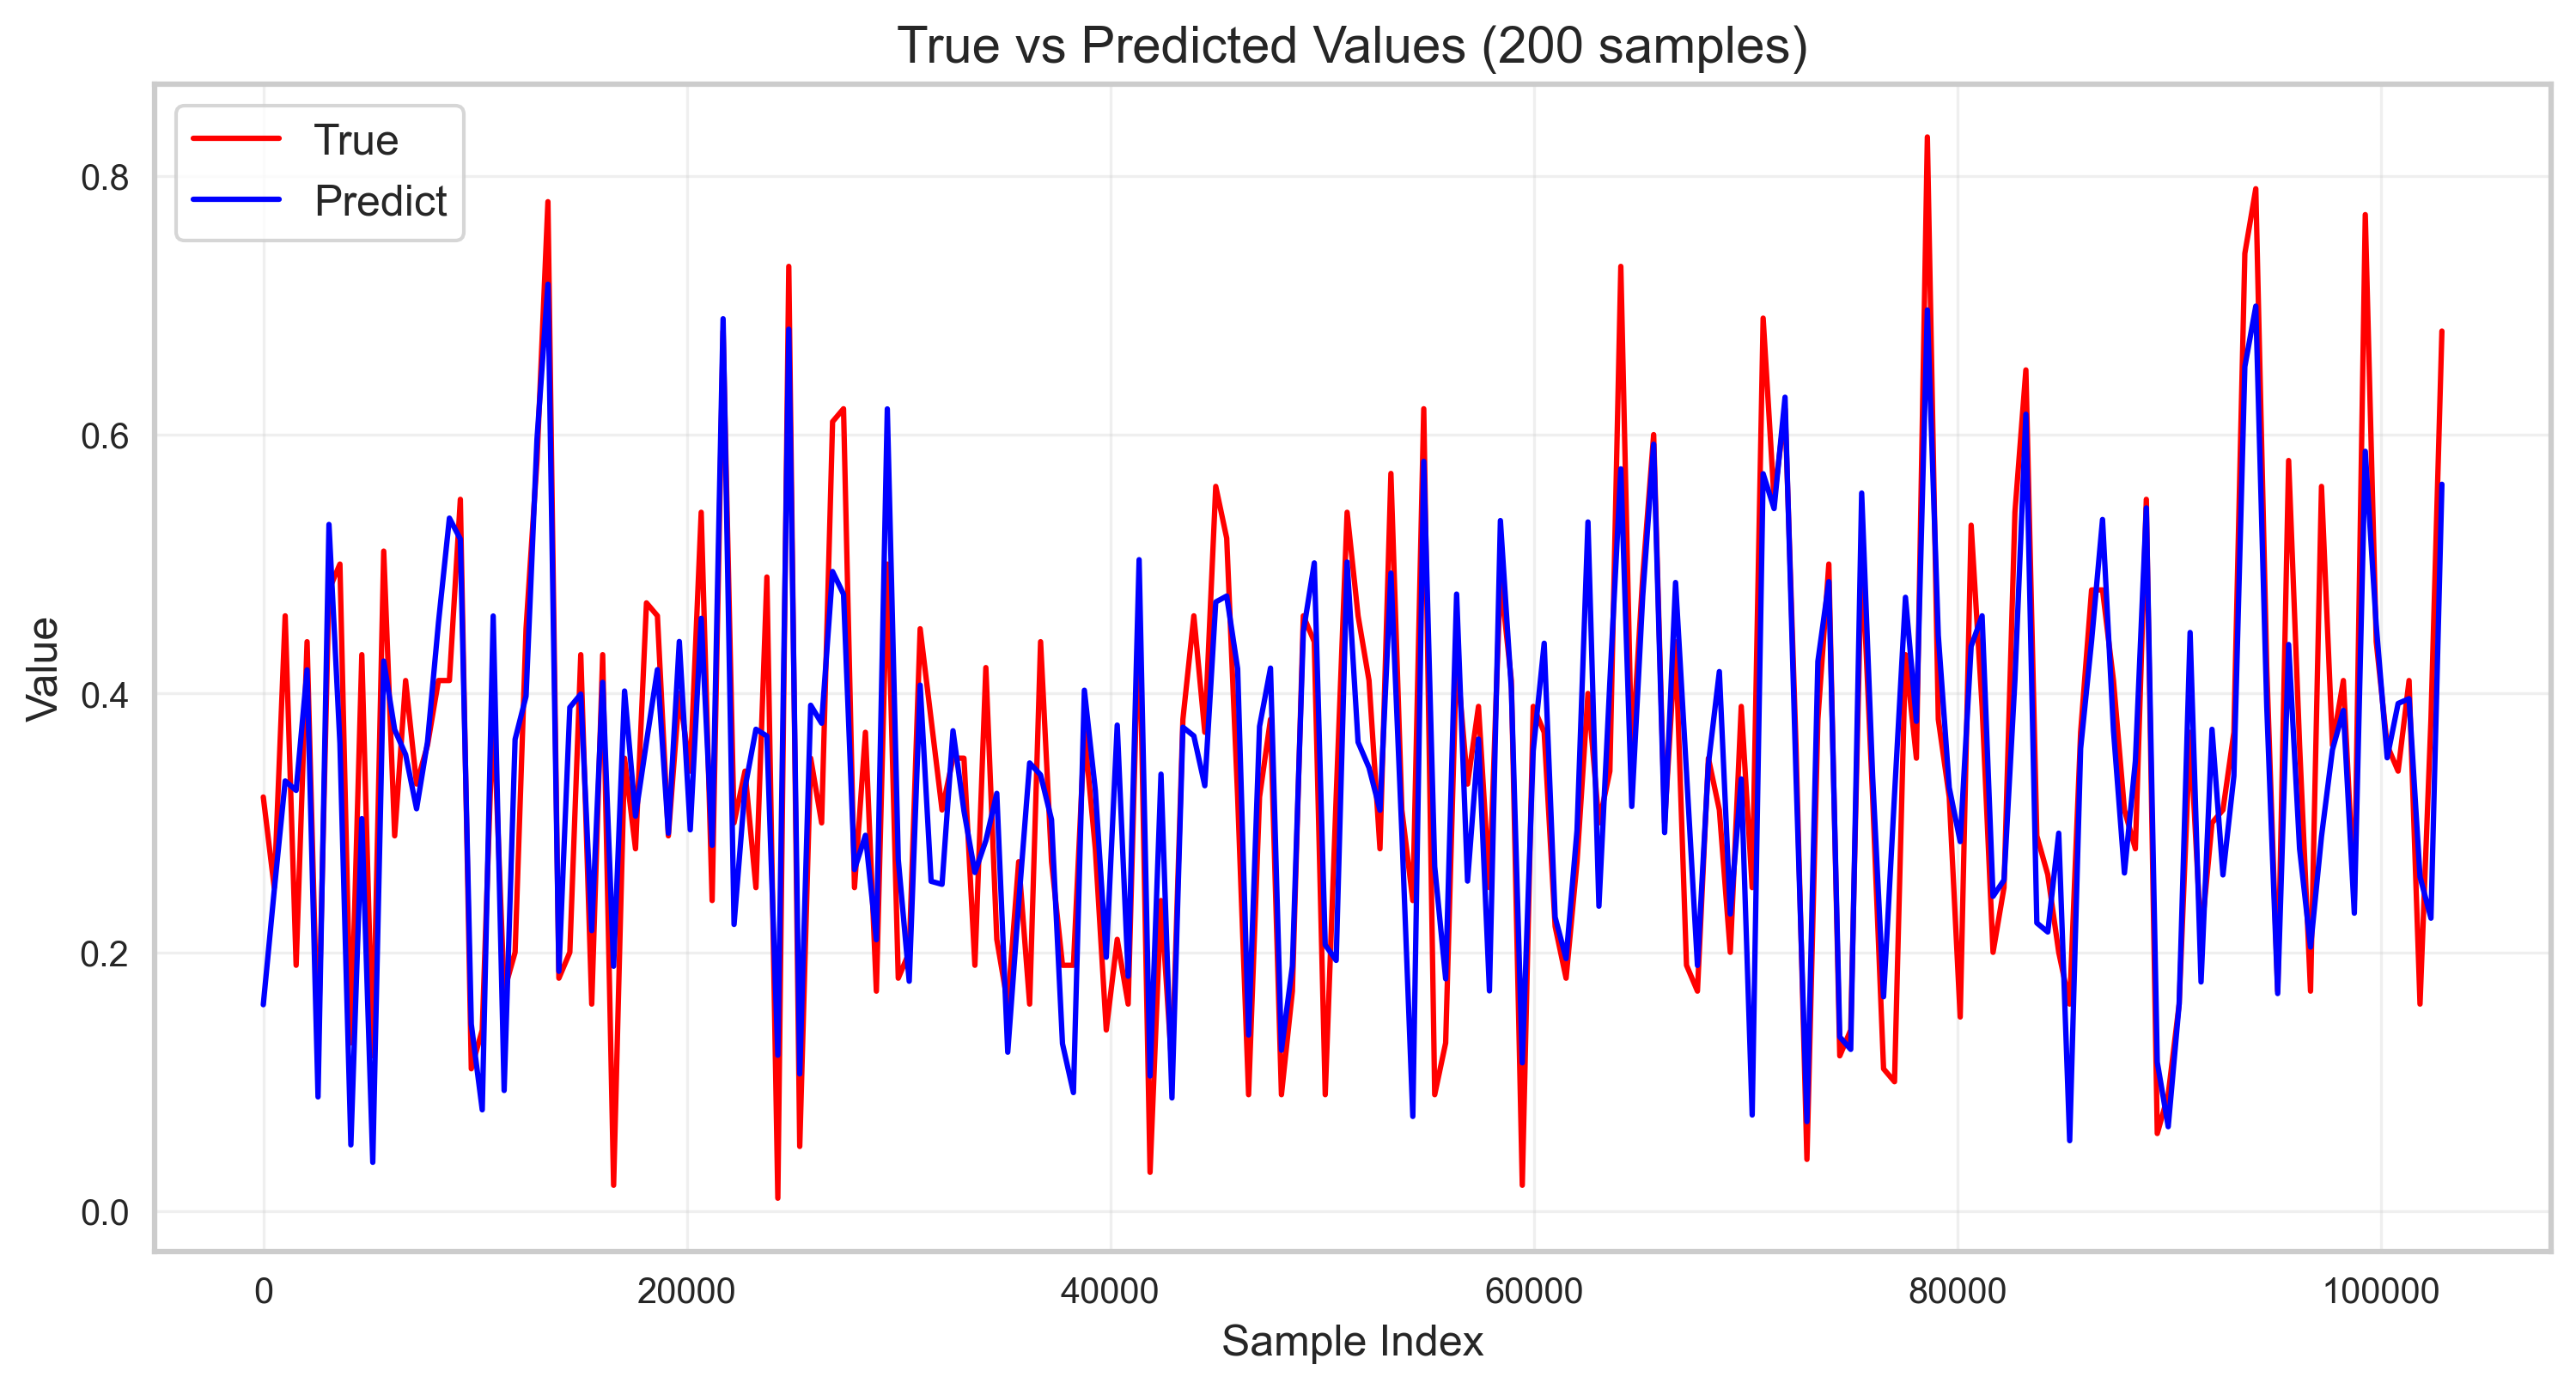

In [65]:
# 抽样数据
y_test_sampled = [y_test.to_list()[i] for i in indices]
ri_pred_sampled = [ri_pred[i] for i in indices]

# 绘制图形
plt.figure(figsize=(12,6))
plt.plot(indices, y_test_sampled, "r", label="True")
plt.plot(indices, ri_pred_sampled, "b", label="Predict")
plt.legend()
plt.title(f"True vs Predicted Values ({len(indices)} samples)")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()

In [66]:
# Model Evaluation
print("Training Set Mean Squared Error (MSE): ", round(mean_squared_error(y_train, ri_pred_train), 4))
print("Training Set Mean Absolute Error(MAE): ", round(mean_absolute_error(y_train, ri_pred_train), 4))
print("Training Set Median Absolute Error(MedAE): ", round(median_absolute_error(y_train, ri_pred_train), 4))
print("Training Set R-squared(R²): ", round(metrics.r2_score(y_train, ri_pred_train), 4))
print("-" * 30)
print("Test Set Mean Squared Error(MSE): ", round(mean_squared_error(y_test, ri_pred), 4))
print("Test Set Mean Absolute Error(MAE): ", round(mean_absolute_error(y_test, ri_pred), 4))
print("Test Set Median Absolute Error(MedAE): ", round(median_absolute_error(y_test, ri_pred), 4))
print("Test Set R-squared: (R²)", round(metrics.r2_score(y_test, ri_pred), 4))

Training Set Mean Squared Error (MSE):  0.0069
Training Set Mean Absolute Error(MAE):  0.0663
Training Set Median Absolute Error(MedAE):  0.0562
Training Set R-squared(R²):  0.7508
------------------------------
Test Set Mean Squared Error(MSE):  0.0069
Test Set Mean Absolute Error(MAE):  0.0662
Test Set Median Absolute Error(MedAE):  0.0561
Test Set R-squared: (R²) 0.7501


### 3.k近邻回归

In [67]:
from sklearn.neighbors import KNeighborsRegressor

In [68]:
kn = KNeighborsRegressor(n_neighbors=5,weights="distance")
kn.fit(X_train,y_train)

KNeighborsRegressor(weights='distance')

In [69]:
kn_pred = kn.predict(X_test)
kn_pred_train = kn.predict(X_train)

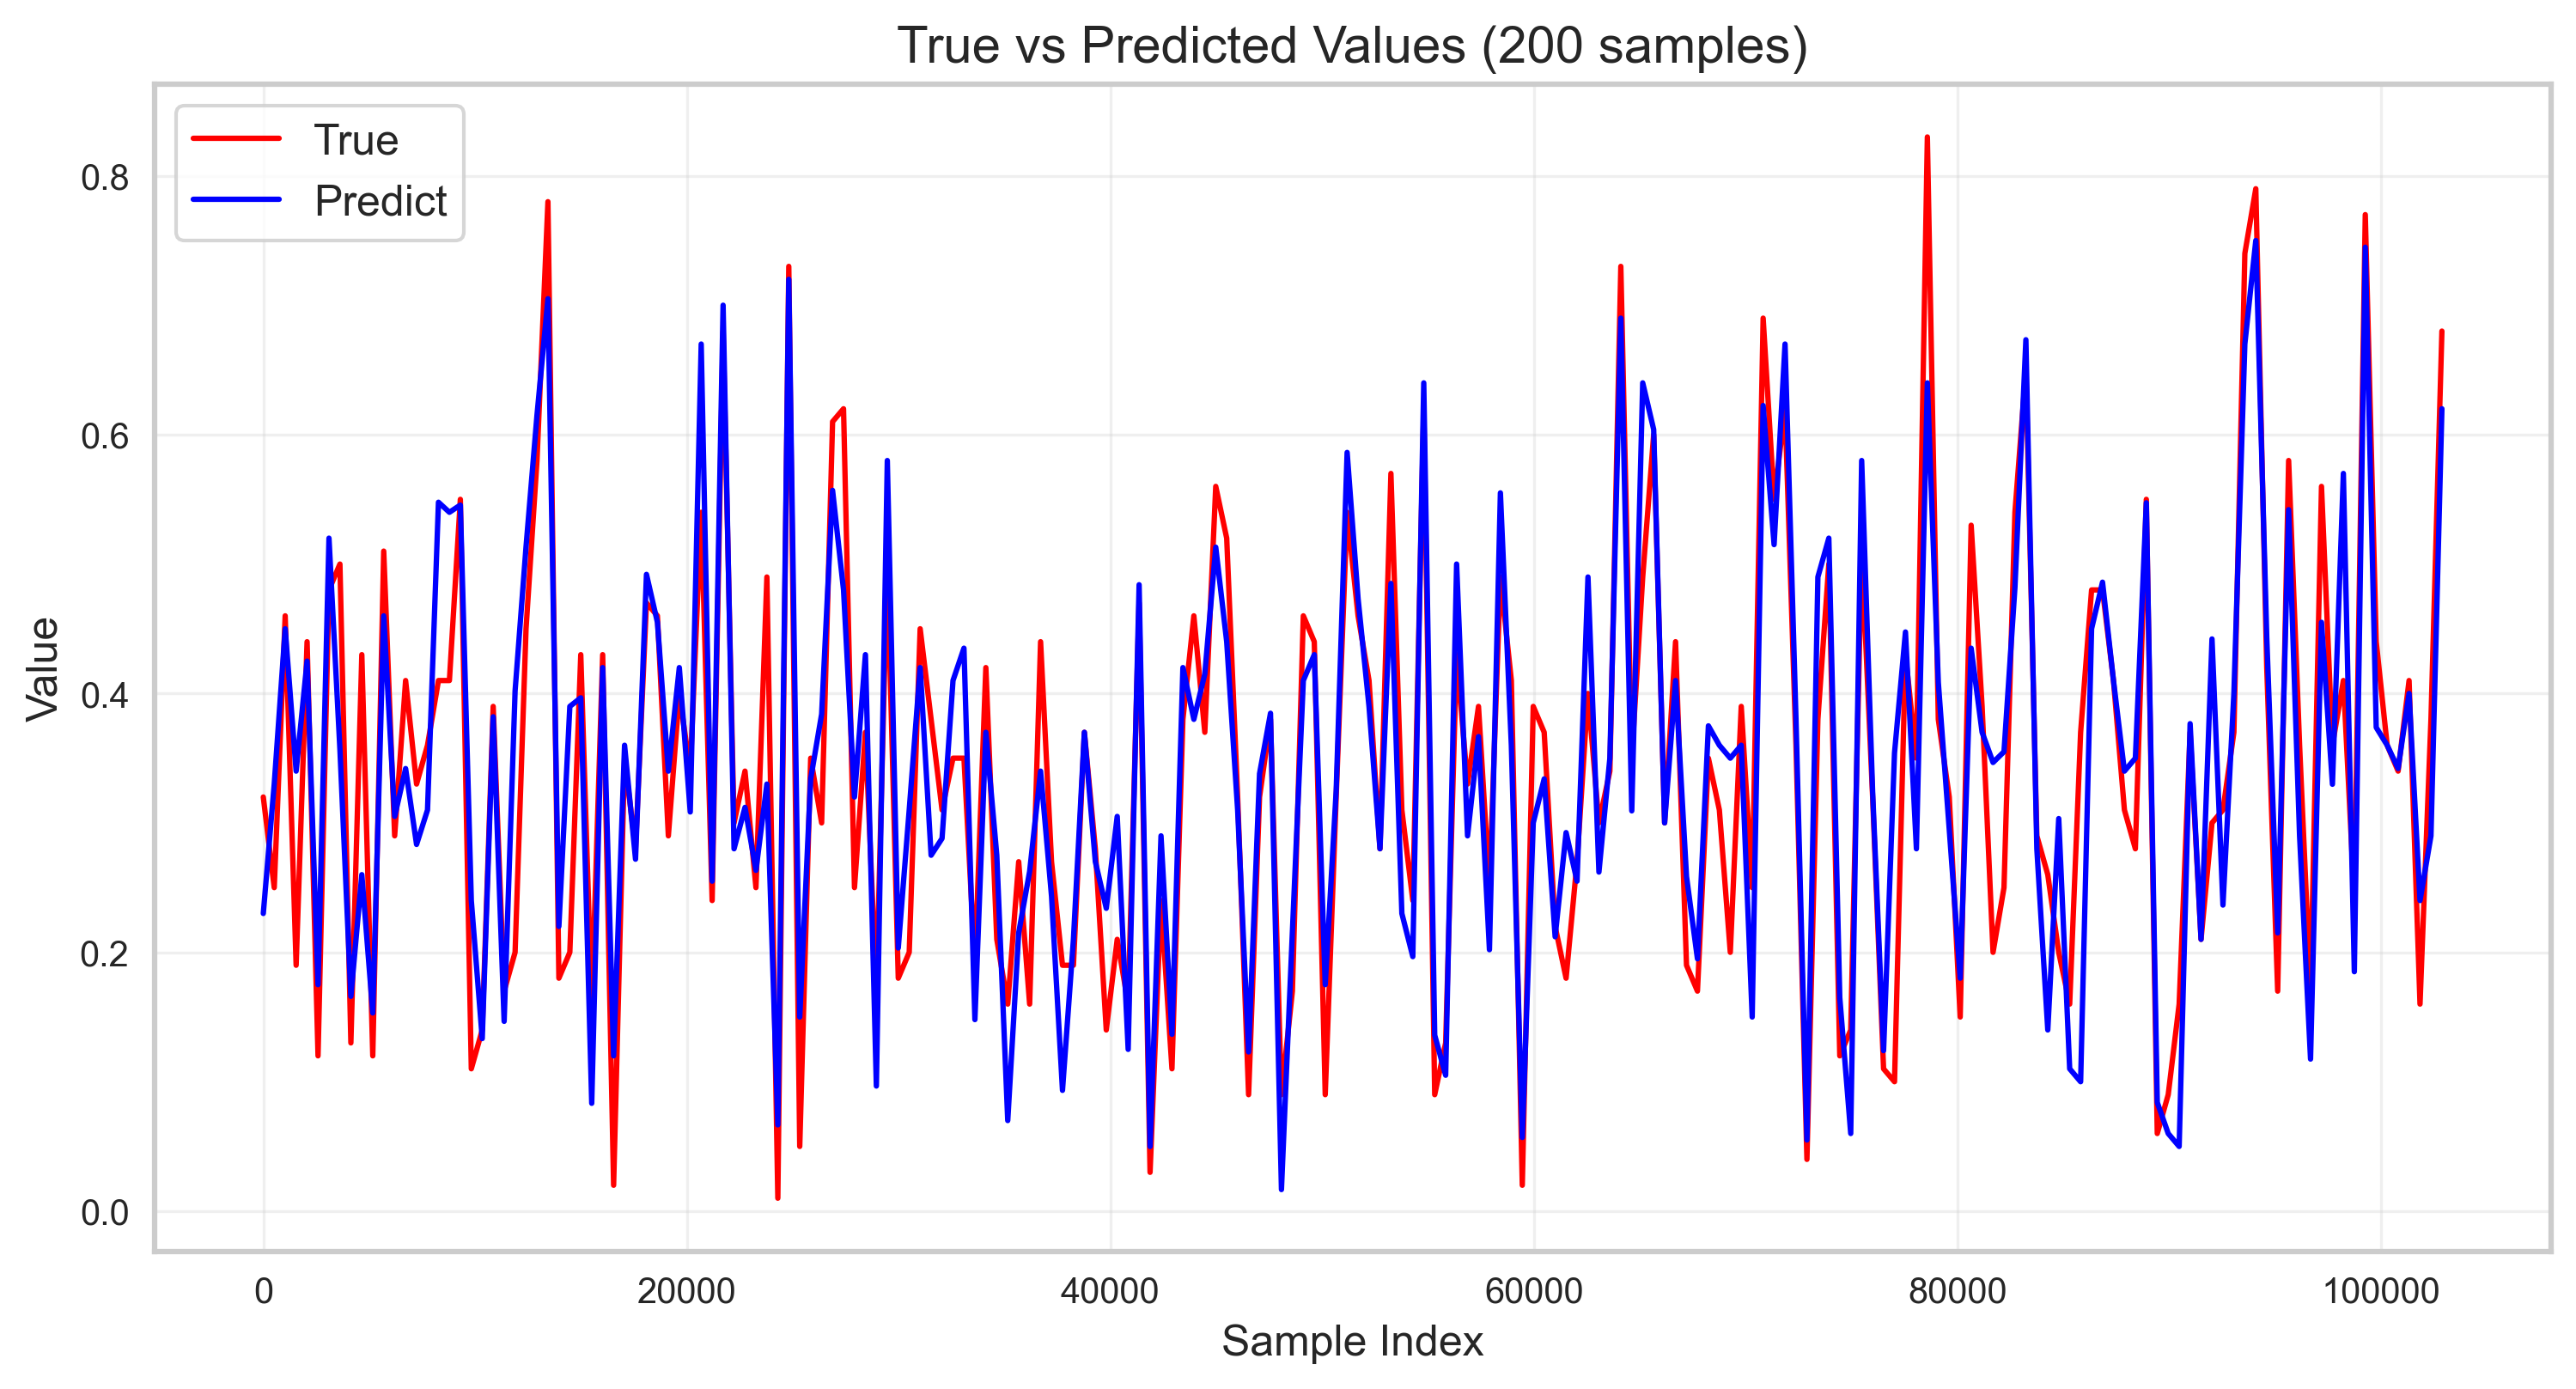

In [70]:
# 抽样数据
y_test_sampled = [y_test.to_list()[i] for i in indices]
kn_pred_sampled = [kn_pred[i] for i in indices]

# 绘制图形
plt.figure(figsize=(12,6))
plt.plot(indices, y_test_sampled, "r", label="True")
plt.plot(indices, kn_pred_sampled, "b", label="Predict")
plt.legend()
plt.title(f"True vs Predicted Values ({len(indices)} samples)")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()

In [71]:
# Model Evaluation
print("Training Set Mean Squared Error (MSE): ", round(mean_squared_error(y_train, kn_pred_train), 4))
print("Training Set Mean Absolute Error(MAE): ", round(mean_absolute_error(y_train, kn_pred_train), 4))
print("Training Set Median Absolute Error(MedAE): ", round(median_absolute_error(y_train, kn_pred_train), 4))
print("Training Set R-squared(R²): ", round(metrics.r2_score(y_train, kn_pred_train), 4))
print("-" * 30)
print("Test Set Mean Squared Error(MSE): ", round(mean_squared_error(y_test, kn_pred), 4))
print("Test Set Mean Absolute Error(MAE): ", round(mean_absolute_error(y_test, kn_pred), 4))
print("Test Set Median Absolute Error(MedAE): ", round(median_absolute_error(y_test, kn_pred), 4))
print("Test Set R-squared: (R²)", round(metrics.r2_score(y_test, kn_pred), 4))

Training Set Mean Squared Error (MSE):  0.0018
Training Set Mean Absolute Error(MAE):  0.0297
Training Set Median Absolute Error(MedAE):  0.0225
Training Set R-squared(R²):  0.9364
------------------------------
Test Set Mean Squared Error(MSE):  0.0047
Test Set Mean Absolute Error(MAE):  0.0529
Test Set Median Absolute Error(MedAE):  0.0432
Test Set R-squared: (R²) 0.8306


### 总结：貌似不太适合线性回归（简单线性回归；正则化的：岭回归、索套回归等等）